# Noiseless_integrable_Traceout

In [1]:
import sys
sys.path.insert(0, '../../../src/')

import numpy as np
import qiskit as qk
import matplotlib.pyplot as plt
import multiprocessing as mp
import tensorflow as tf
import random
import pickle as pkl
import scipy

from src import *
from qiskit.quantum_info import Operator

from kraus_channels import isomery_to_kraus
from spectrum import *
from analysis import *

from kraus_channels import KrausMap
from quantum_channel import DilutedChannel


#np.set_printoptions(threshold=sys.maxsize)
np.set_printoptions(precision=1)

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"


/tmp/ipykernel_6134/4154115429.py:5: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  import qiskit as qk
2025-10-16 12:59:02.295930: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-16 12:59:02.307552: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-16 12:59:02.709333: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations,

# Inspect spectrum

In [2]:
def integrable_circuit_tuned(n, L, couple):
    theta_list = [np.random.uniform(-np.pi, np.pi, n) for i in range(L)]
    sqrt_iSWAP = iSwapGate().power(1 / 2)
    tuned_coup = iSwapGate().power(couple)

    circuit = qk.QuantumCircuit(n)
    for i, theta in enumerate(theta_list):

        offset = i%2
        for j in range(n):
            circuit.rz(theta[j], j)

        for j in range((n - offset) // 2):
            if j + offset != 2:  # tune the coupling in the middle of the chain
                circuit.append(sqrt_iSWAP, [2 * j + offset, 2 * j + 1 + offset])
            else:
                circuit.append(tuned_coup, [2 * j + offset, 2 * j + 1 + offset])
            

    return circuit

In [ ]:
p_5 = 0.205
r_5 = 12

p_20 = 0.45
r_20 = 17

p_50 = 0.65
r_50 = 47

In [132]:
csr_list = []
for i in range(10):
    np.random.seed(42 + i) # different seeds for each realization|
    circuit_target = integrable_circuit_tuned(5, 5, 1/100)
    U = Operator(circuit_target).data

    kraus_map = isomery_to_kraus(U, 2)
    kraus_chaos = KrausMap(2**4, rank=r_5)
    kraus_map = DilutedChannel(kraus_map, kraus_chaos, p_5)
    spectrum = channel_spectrum(kraus_map)
    csr = complex_spacing_ratio(spectrum)
    csr_list.append(csr)

    radial_list = spectrum_to_radial(csr_list)
angular_list = spectrum_to_angular(csr_list)

r_mean_L5_U, a_mean_L5_U = scatterplot_stats(radial_list, angular_list)

In [119]:
from kraus_channels import KrausMap
from quantum_channel import DilutedChannel

csr_list = []
for i in range(10):
    np.random.seed(42 + i) # different seeds for each realization|
    circuit_target = integrable_circuit_tuned(5, 20, 1/100)
    U = Operator(circuit_target).data

    kraus_map = isomery_to_kraus(U, 2)
    kraus_chaos = KrausMap(2**4, rank=r_20)
    kraus_map = DilutedChannel(kraus_map, kraus_chaos, p_20)
    spectrum = channel_spectrum(kraus_map)
    csr = complex_spacing_ratio(spectrum)
    csr_list.append(csr)

radial_list = spectrum_to_radial(csr_list)
angular_list = spectrum_to_angular(csr_list)

r_mean_L20_U, a_mean_L20_U = scatterplot_stats(radial_list, angular_list)

In [118]:
from kraus_channels import KrausMap
from quantum_channel import DilutedChannel

csr_list = []
for i in range(10):
    np.random.seed(42 + i) # different seeds for each realization|
    circuit_target = integrable_circuit_tuned(5, 50, 1/100)
    U = Operator(circuit_target).data

    kraus_map = isomery_to_kraus(U, 2)
    kraus_chaos = KrausMap(2**4, rank=r_50)
    kraus_map = DilutedChannel(kraus_map, kraus_chaos, p_50)
    spectrum = channel_spectrum(kraus_map)
    csr = complex_spacing_ratio(spectrum)
    csr_list.append(csr)

radial_list = spectrum_to_radial(csr_list)
angular_list = spectrum_to_angular(csr_list)

r_mean_L50_U, a_mean_L50_U = scatterplot_stats(radial_list, angular_list)

# Weak

In [127]:
csr_list = []
for i in range(10):
    np.random.seed(42 + i) # different seeds for each realization|
    circuit_target = integrable_circuit_tuned(5, 5, 1/8)
    U = Operator(circuit_target).data

    kraus_map = isomery_to_kraus(U, 2)
    kraus_chaos = KrausMap(2**4, rank=r_5)
    kraus_map = DilutedChannel(kraus_map, kraus_chaos, p_5)
    spectrum = channel_spectrum(kraus_map)
    csr = complex_spacing_ratio(spectrum)
    csr_list.append(csr)

    radial_list = spectrum_to_radial(csr_list)
angular_list = spectrum_to_angular(csr_list)

r_mean_L5_weak, a_mean_L5_weak = scatterplot_stats(radial_list, angular_list)

In [116]:
csr_list = []
for i in range(10):
    np.random.seed(42 + i) # different seeds for each realization|
    circuit_target = integrable_circuit_tuned(5, 20, 1/8)
    U = Operator(circuit_target).data

    kraus_map = isomery_to_kraus(U, 2)
    kraus_chaos = KrausMap(2**4, rank=r_20)
    kraus_map = DilutedChannel(kraus_map, kraus_chaos, p_20)
    spectrum = channel_spectrum(kraus_map)
    csr = complex_spacing_ratio(spectrum)
    csr_list.append(csr)

    radial_list = spectrum_to_radial(csr_list)
angular_list = spectrum_to_angular(csr_list)

r_mean_L20_weak, a_mean_L20_weak = scatterplot_stats(radial_list, angular_list)

In [115]:
csr_list = []
for i in range(10):
    np.random.seed(42 + i) # different seeds for each realization|
    circuit_target = integrable_circuit_tuned(5, 50, 1/8)
    U = Operator(circuit_target).data

    kraus_map = isomery_to_kraus(U, 2)
    kraus_chaos = KrausMap(2**4, rank=r_50)
    kraus_map = DilutedChannel(kraus_map, kraus_chaos, p_50)
    spectrum = channel_spectrum(kraus_map)
    csr = complex_spacing_ratio(spectrum)
    csr_list.append(csr)

    radial_list = spectrum_to_radial(csr_list)
angular_list = spectrum_to_angular(csr_list)

r_mean_L50_weak, a_mean_L50_weak = scatterplot_stats(radial_list, angular_list)

# Strong

In [133]:
csr_list = []
for i in range(10):
    np.random.seed(42 + i) # different seeds for each realization|
    circuit_target = integrable_circuit_tuned(5, 5, 1/2)
    U = Operator(circuit_target).data

    kraus_map = isomery_to_kraus(U, 2)
    kraus_chaos = KrausMap(2**4, rank=r_5)
    kraus_map = DilutedChannel(kraus_map, kraus_chaos, p_5)
    spectrum = channel_spectrum(kraus_map)
    csr = complex_spacing_ratio(spectrum)
    csr_list.append(csr)

    radial_list = spectrum_to_radial(csr_list)
angular_list = spectrum_to_angular(csr_list)

r_mean_L5_strong, a_mean_L5_strong = scatterplot_stats(radial_list, angular_list)

In [113]:
csr_list = []
for i in range(10):
    np.random.seed(42 + i) # different seeds for each realization|
    circuit_target = integrable_circuit_tuned(5, 20, 1/2)
    U = Operator(circuit_target).data

    kraus_map = isomery_to_kraus(U, 2)
    kraus_chaos = KrausMap(2**4, rank=r_20)
    kraus_map = DilutedChannel(kraus_map, kraus_chaos, p_20)
    spectrum = channel_spectrum(kraus_map)
    csr = complex_spacing_ratio(spectrum)
    csr_list.append(csr)

    radial_list = spectrum_to_radial(csr_list)
angular_list = spectrum_to_angular(csr_list)

r_mean_L20_strong, a_mean_L20_strong = scatterplot_stats(radial_list, angular_list)

In [112]:
csr_list = []
for i in range(10):
    np.random.seed(42 + i) # different seeds for each realization|
    circuit_target = integrable_circuit_tuned(5, 50, 1/2)
    U = Operator(circuit_target).data

    kraus_map = isomery_to_kraus(U, 2)
    kraus_chaos = KrausMap(2**4, rank=r_50)
    kraus_map = DilutedChannel(kraus_map, kraus_chaos, p_50)
    spectrum = channel_spectrum(kraus_map)
    csr = complex_spacing_ratio(spectrum)
    csr_list.append(csr)

    radial_list = spectrum_to_radial(csr_list)
angular_list = spectrum_to_angular(csr_list)

r_mean_L50_strong, a_mean_L50_strong = scatterplot_stats(radial_list, angular_list)

## Plot

In [129]:
r_mean_weak = [r_mean_L5_weak, r_mean_L20_weak, r_mean_L50_weak]
a_mean_weak = [a_mean_L5_weak, a_mean_L20_weak, a_mean_L50_weak]

r_mean_strong = [r_mean_L5_strong, r_mean_L20_strong, r_mean_L50_strong]
a_mean_strong = [a_mean_L5_strong, a_mean_L20_strong, a_mean_L50_strong]

r_mean_U = [r_mean_L5_U, r_mean_L20_U, r_mean_L50_U]
a_mean_U = [a_mean_L5_U, a_mean_L20_U, a_mean_L50_U]

In [104]:
r_AI, a_AI = [0.730667, 0.198494]
r_FF, a_FF = [0.617735, -0.0961044]  # from FF paper

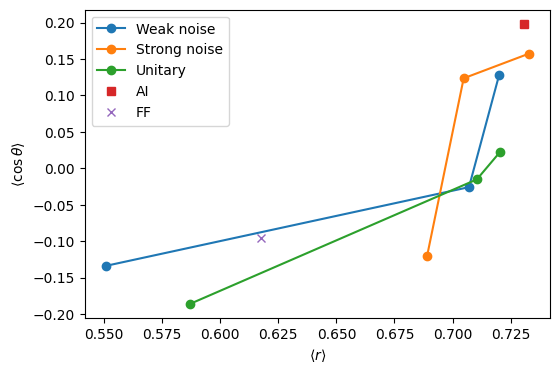

In [134]:

plt.figure(figsize=(6,4))
plt.plot(r_mean_weak, a_mean_weak, 'o-', label='Weak noise')
plt.plot(r_mean_strong, a_mean_strong, 'o-', label='Strong noise')
plt.plot(r_mean_U, a_mean_U, 'o-', label='Unitary')

plt.plot(r_AI, a_AI, 's', label='AI')
plt.plot(r_FF, a_FF, 'x', label='FF')
plt.xlabel(r'$\langle r \rangle$')
plt.ylabel(r'$\langle \cos \theta \rangle$')
plt.legend()